# AI4QC-2 Sentinel-2 L1C (JP2) — Step-by-step debug notebook
This notebook mirrors the `s2_l1c_data.py` pipeline, but runs interactively and plots intermediate steps (as James suggested).

## 0) Parameters
Edit these and run the notebook top-to-bottom.

In [18]:
# Choose ONE tile and a date range. The notebook will:
#  1) discover all L1C products for this tile between START_DATE and END_DATE
#  2) pick one product for step-by-step debugging (DEBUG_PRODUCT_INDEX)
#  3) optionally build a time-stacked Zarr cube at the end.
#
# Notes:
# - AWS Sentinel-2 bucket uses non-zero-padded month/day in the 'products' path: .../2025/7/9/...
# - Stored data is physically meaningful reflectance = DN/10000. No percentile stretch is applied to storage.
# - Any clipping/stretching is only for plotting quicklooks.

IN_BUCKET = "sentinel-s2-l1c"

TILE = "56FQF"                 # e.g. "56FQF"
START_DATE = "2015-06-01"      # YYYY-MM-DD (inclusive)
END_DATE   = "2025-12-31"      # YYYY-MM-DD (inclusive)
DEBUG_PRODUCT_INDEX = 0        # which product in the discovered list to use for debug plots

OUT_DIM = 128
BANDS = ["B01","B02","B03","B04","B05","B06","B07","B08","B8A","B09","B11","B12"]
QUANTIFICATION_VALUE = 10000.0
COVERAGE_THRESHOLD = 0.01  # fraction in [0,1]

# Zarr output name (local). A time-stacked cube will use this name.
ZARR_NAME = f"s2_l1c_tile_{TILE}_{START_DATE}_to_{END_DATE}.zarr"

USE_DEBUG_DOWNSCALE = True   # True for single-product debug plots; False for bulk time stack
PID_DTYPE_LEN = 128

MAX_WORKERS = 10
DL_THREADS_PER_WORKER = 2   # 4–6 is usually enough
BATCH_SIZE = 128             # 16 or 32 recommended (optional; see section 3)
USE_BATCH_WRITES = True     # set False to keep current time=1 appends

## 1) Imports

In [19]:
from __future__ import annotations

import os
import re
import json
import shutil
import tempfile
import datetime as dt
from typing import Dict, List, Optional, Tuple

import boto3
import numpy as np
import rasterio
from rasterio.enums import Resampling
from rasterio.transform import Affine
from rasterio.warp import reproject
import xarray as xr
from PIL import Image

import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor
from itertools import repeat
from rasterio.session import AWSSession
from botocore.session import Session as BotocoreSession

RUN_DIR = "/home/ubuntu/ai4qc2_run"   # must be on a big disk
TMP_ROOT = os.path.join(RUN_DIR, "tmp_workers")
ZARR_DIR = os.path.join(RUN_DIR, "zarr_out")
CACHE_DIR = os.path.join(RUN_DIR, "cache")
LOG_DIR = os.path.join(RUN_DIR, "logs")

for d in [RUN_DIR, TMP_ROOT, ZARR_DIR, CACHE_DIR, LOG_DIR]:
    os.makedirs(d, exist_ok=True)


In [20]:
from botocore.config import Config

S3_CONFIG = Config(
    retries={"max_attempts": 12, "mode": "adaptive"},
    connect_timeout=30,
    read_timeout=120,
)

def log_failure(log_path: str, pid: str, stage: str, err: Exception):
    rec = {
        "product_id": pid,
        "stage": stage,
        "error": repr(err),
        "ts_utc": dt.datetime.utcnow().isoformat() + "Z",
    }
    with open(log_path, "a") as f:
        f.write(json.dumps(rec) + "\n")

## 2) Helpers (same as script)

In [21]:
def parse_s3_uri(uri: str) -> Tuple[str, str]:
    if not uri.startswith("s3://"):
        raise ValueError(f"Not an s3:// URI: {uri}")
    parts = uri[5:].split("/", 1)
    bucket = parts[0]
    key = parts[1] if len(parts) > 1 else ""
    return bucket, key

def ensure_trailing_slash(s: str) -> str:
    return s if s.endswith("/") else s + "/"

def get_mgrs_tile_from_product_id(product_id: str) -> str:
    m = re.search(r"_T(\d{2}[A-Z]{3})_", product_id)
    if not m:
        raise ValueError(f"Could not parse MGRS tile from product id: {product_id}")
    return m.group(1)

def extract_datetime_token(product_id: str) -> str:
    m = re.search(r"_(\d{8}T\d{6})_", product_id)
    if not m:
        raise ValueError(f"Could not extract datetime token from product id: {product_id}")
    return m.group(1)

def list_s3_objects_requester_pays(s3_client, bucket: str, prefix: str) -> List[str]:
    paginator = s3_client.get_paginator("list_objects_v2")
    keys: List[str] = []
    for page in paginator.paginate(Bucket=bucket, Prefix=prefix, RequestPayer="requester"):
        for obj in page.get("Contents", []):
            keys.append(obj["Key"])
    return keys

def download_s3_object_requester_pays(s3_client, bucket: str, key: str, local_path: str) -> None:
    os.makedirs(os.path.dirname(local_path), exist_ok=True)
    s3_client.download_file(bucket, key, local_path, ExtraArgs={"RequestPayer": "requester"})

def _is_bad_key(k: str) -> bool:
    kl = k.lower()
    base = os.path.basename(kl)
    if not kl.endswith(".jp2"):
        return True
    if "/preview/" in kl:
        return True
    if "/qi_data/" in kl or "/aux_data/" in kl:
        return True
    if base.startswith("msk") or "msk" in base or "mask" in base:
        return True
    if base == "tci.jp2" or base.endswith("_tci.jp2"):
        return True
    return False

BAND_RES = {
    "B01": "R60m",
    "B02": "R10m",
    "B03": "R10m",
    "B04": "R10m",
    "B05": "R20m",
    "B06": "R20m",
    "B07": "R20m",
    "B08": "R10m",
    "B8A": "R20m",
    "B09": "R60m",
    "B10": "R60m",
    "B11": "R20m",
    "B12": "R20m",
}

def _key_rank_for_band(k: str, want_res: str | None) -> tuple:
    kl = k.lower()

    # Prefer IMG_DATA paths (most "real" assets live here)
    img_data = 0 if "/img_data/" in kl else 1

    # Strongly penalize the suspicious "/0/" segment
    zero_seg = 1 if "/0/" in kl else 0

    # Prefer explicit resolution folder match (if we know it)
    res_ok = 0
    if want_res is not None:
        res_ok = 0 if f"/{want_res.lower()}/" in kl else 1

    # Prefer longer, more specific keys over tiny stubs (after the above criteria)
    return (img_data, zero_seg, res_ok, len(k))

def find_jp2_band_keys(all_keys: List[str], bands: List[str]) -> Dict[str, str]:
    keys = [k for k in all_keys if not _is_bad_key(k)]

    def matches_band(k: str, band: str) -> bool:
        base = os.path.basename(k)
        return base == f"{band}.jp2" or base.endswith(f"_{band}.jp2")

    band_to_key: Dict[str, str] = {}
    for band in bands:
        candidates = [k for k in keys if matches_band(k, band)]
        if not candidates:
            some = sorted({os.path.basename(x) for x in keys})[:30]
            raise RuntimeError(
                f"No JP2 found for band {band} after filtering. Example JP2 basenames seen: {some}"
            )

        want_res = BAND_RES.get(band)

        # Sort by our robust ranking (avoid /0/, prefer IMG_DATA + resolution)
        candidates_sorted = sorted(candidates, key=lambda k: _key_rank_for_band(k, want_res))

        band_to_key[band] = candidates_sorted[0]

    return band_to_key

def log_mask_and_dtype(jp2_path: str) -> None:
    with rasterio.open(jp2_path) as src:
        mask_flags = src.mask_flag_enums[0] if src.count >= 1 else []
        print(f"[{os.path.basename(jp2_path)}] dtype={src.dtypes[0]} nodata={src.nodata} mask_flags={mask_flags}")
        m = src.read_masks(1, out_shape=(min(64, src.height), min(64, src.width)))
        print(f"[{os.path.basename(jp2_path)}] mask sample unique={np.unique(m)[:10]}")

def tile_to_tiles_prefix(tile: str, sensing_date: dt.date) -> str:
    utm = tile[:2]
    lat = tile[2]
    grid = tile[3:]
    y = f"{sensing_date.year:04d}"
    m = str(sensing_date.month)
    d = str(sensing_date.day)
    return f"tiles/{utm}/{lat}/{grid}/{y}/{m}/{d}/"

def sensing_date_from_product_id(product_id: str) -> dt.date:
    tok = extract_datetime_token(product_id)  # YYYYMMDDThhmmss
    return dt.datetime.strptime(tok, "%Y%m%dT%H%M%S").date()


In [22]:
def iter_dates(start_date: str, end_date: str) -> List[dt.date]:
    s = dt.date.fromisoformat(start_date)
    e = dt.date.fromisoformat(end_date)
    if e < s:
        raise ValueError("END_DATE must be >= START_DATE")
    out = []
    d = s
    while d <= e:
        out.append(d)
        d += dt.timedelta(days=1)
    return out

def list_common_prefixes_requester_pays(
    s3_client, bucket: str, prefix: str, delimiter: str = "/"
) -> List[str]:
    paginator = s3_client.get_paginator("list_objects_v2")
    cps: List[str] = []

    printed = False
    for page in paginator.paginate(
        Bucket=bucket, Prefix=prefix, Delimiter=delimiter, RequestPayer="requester"
    ):
        if not printed:
            printed = True
            print("DEBUG list_objects_v2")
            print("  bucket:", bucket)
            print("  prefix:", prefix)
            print("  keys:", list(page.keys()))
            print("  KeyCount:", page.get("KeyCount"))
            print("  IsTruncated:", page.get("IsTruncated"))
            print("  CommonPrefixes:", len(page.get("CommonPrefixes", [])))
            print("  Contents:", len(page.get("Contents", [])))
            if page.get("CommonPrefixes"):
                print("  first CommonPrefix:", page["CommonPrefixes"][0]["Prefix"])
            if page.get("Contents"):
                print("  first Content key:", page["Contents"][0]["Key"])

        for cp in page.get("CommonPrefixes", []):
            cps.append(cp["Prefix"])

    return cps

def list_products_for_tile_in_range(
    s3_client, bucket: str, tile: str, start_date: str, end_date: str
) -> List[str]:
    """Return a list of SAFE prefixes (s3 keys ending in '.SAFE/') for a tile/date range."""
    safes: List[str] = []
    for d in iter_dates(start_date, end_date):
        # IMPORTANT: AWS uses non-zero-padded M/D in the prefix.
        y = f"{d.year:04d}"
        m = str(d.month)
        day = str(d.day)
        day_prefix = f"products/{y}/{m}/{day}/"
        # list product directories under this day
        product_prefixes = list_common_prefixes_requester_pays(s3_client, bucket, day_prefix)
        for pfx in product_prefixes:
            # pfx looks like: products/2025/7/19/<PRODUCT>.SAFE/
            prod = pfx.rstrip("/").split("/")[-1]
            # Filter to Sentinel-2 L1C products for this tile
            if (f"_T{tile}_" in prod) and ("MSIL1C" in prod):
                safes.append(pfx)

    # Sort by sensing datetime token if present
    def _sort_key(pfx: str) -> str: 
        prod = pfx.rstrip("/").split("/")[-1]
        try:
            return extract_datetime_token(prod)
        except Exception:
            return prod
    return sorted(safes, key=_sort_key)

def safe_prefix_to_product_id(safe_prefix: str) -> str:
    pid = safe_prefix.rstrip("/").split("/")[-1]
    if pid.endswith(".SAFE"):
        pid = pid[:-5]
    return pid


def sensing_time_from_product_id(product_id: str) -> np.datetime64:
    tok = extract_datetime_token(product_id)  # YYYYMMDDThhmmss
    # Convert to numpy datetime64[ns]
    dt_obj = dt.datetime.strptime(tok, "%Y%m%dT%H%M%S")  # no tzinfo
    return np.datetime64(dt_obj, "ns")


## 3) Locate and download JP2s (Requester Pays)
This mirrors your `process_one_safe` selection logic, but keeps files locally so we can plot intermediate arrays.

In [23]:
import os, json, boto3

session = boto3.Session(profile_name="source-keys")
s3 = session.client("s3", config=S3_CONFIG)

cache_path = os.path.join(CACHE_DIR, f"safe_prefixes_{TILE}_{START_DATE}_{END_DATE}.json")

if os.path.exists(cache_path):
    with open(cache_path, "r") as f:
        safe_prefixes = json.load(f)
    print(f"Loaded cached SAFE prefixes: {len(safe_prefixes)} from {cache_path}")
else:
    safe_prefixes = list_products_for_tile_in_range(s3, IN_BUCKET, TILE, START_DATE, END_DATE)
    with open(cache_path, "w") as f:
        json.dump(safe_prefixes, f)
    print(f"Discovered and cached SAFE prefixes: {len(safe_prefixes)} to {cache_path}")

safe_prefixes[:5]

Loaded cached SAFE prefixes: 830 from /home/ubuntu/ai4qc2_run/cache/safe_prefixes_56FQF_2015-06-01_2025-12-31.json


['products/2016/12/7/S2A_MSIL1C_20161207T231132_N0204_R058_T56FQF_20161207T231127/',
 'products/2016/12/17/S2A_MSIL1C_20161217T231122_N0204_R058_T56FQF_20161217T231124/',
 'products/2016/12/27/S2A_MSIL1C_20161227T231122_N0204_R058_T56FQF_20161227T231124/',
 'products/2017/1/6/S2A_MSIL1C_20170106T231121_N0204_R058_T56FQF_20170106T231120/',
 'products/2017/1/16/S2A_MSIL1C_20170116T231121_N0204_R058_T56FQF_20170116T231119/']

In [24]:
# Pick one product to debug in the rest of the notebook.
# print("Found", len(safe_prefixes), "SAFE prefixes")
# print("First 20:")
for p in safe_prefixes[:20]:
    print(p)

if not safe_prefixes:
    raise RuntimeError("No products found for the requested tile/date range.")

SAFE_PREFIX = "s3://" + IN_BUCKET + "/" + safe_prefixes[DEBUG_PRODUCT_INDEX]
in_bucket, in_prefix = parse_s3_uri(SAFE_PREFIX)
in_prefix = ensure_trailing_slash(in_prefix)
product_id = in_prefix.rstrip("/").split("/")[-1]
tile = get_mgrs_tile_from_product_id(product_id)

dt_token = extract_datetime_token(product_id)  # YYYYMMDDThhmmss
print("DEBUG product_id:", product_id)
print("DEBUG sensing token:", dt_token)


products/2016/12/7/S2A_MSIL1C_20161207T231132_N0204_R058_T56FQF_20161207T231127/
products/2016/12/17/S2A_MSIL1C_20161217T231122_N0204_R058_T56FQF_20161217T231124/
products/2016/12/27/S2A_MSIL1C_20161227T231122_N0204_R058_T56FQF_20161227T231124/
products/2017/1/6/S2A_MSIL1C_20170106T231121_N0204_R058_T56FQF_20170106T231120/
products/2017/1/16/S2A_MSIL1C_20170116T231121_N0204_R058_T56FQF_20170116T231119/
products/2017/2/5/S2A_MSIL1C_20170205T231121_N0204_R058_T56FQF_20170205T231124/
products/2017/2/15/S2A_MSIL1C_20170215T231121_N0204_R058_T56FQF_20170215T231124/
products/2017/2/25/S2A_MSIL1C_20170225T231121_N0204_R058_T56FQF_20170225T231124/
products/2017/3/7/S2A_MSIL1C_20170307T231121_N0204_R058_T56FQF_20170307T231122/
products/2017/3/17/S2A_MSIL1C_20170317T231121_N0204_R058_T56FQF_20170317T231121/
products/2017/3/27/S2A_MSIL1C_20170327T231131_N0204_R058_T56FQF_20170327T231125/
products/2017/4/6/S2A_MSIL1C_20170406T231131_N0204_R058_T56FQF_20170406T231128/
products/2017/4/16/S2A_MSIL1C_

In [25]:
# List JP2s inside the tile/day prefix and pick one JP2 per requested band.
# Derive sensing date from product_id (you already have dt_token)
dt_obj = dt.datetime.strptime(dt_token, "%Y%m%dT%H%M%S")
sensing_date = dt_obj.date()

tiles_prefix = tile_to_tiles_prefix(tile, sensing_date)
print("Using tiles prefix:", tiles_prefix)

all_keys = list_s3_objects_requester_pays(s3, in_bucket, tiles_prefix)
# Show what B01 candidates actually exist under this prefix
b01_cands = [
    k for k in all_keys
    if k.lower().endswith(".jp2")
    and (os.path.basename(k) == "B01.jp2" or os.path.basename(k).endswith("_B01.jp2"))
]
print("B01 candidates:", len(b01_cands))
print("First 20 B01 candidates:")
for k in sorted(b01_cands)[:20]:
    print(" ", k)

print("Any IMG_DATA?", any("/img_data/" in k.lower() for k in b01_cands))
print("Any /0/?", any("/0/" in k.lower() for k in b01_cands))

print("Total keys under tiles prefix:", len(all_keys))
print("JP2 under tiles prefix:", sum(k.lower().endswith(".jp2") for k in all_keys))

band_to_key = find_jp2_band_keys(all_keys, BANDS)

print("Chosen S3 keys (first 3):")
for b in ["B01", "B02", "B03"]:
    print(b, "->", band_to_key[b])
    
tmp = tempfile.mkdtemp(prefix="ai4qc2_nb_")
local_safe_dir = os.path.join(tmp, product_id)
os.makedirs(local_safe_dir, exist_ok=True)

band_local_paths: Dict[str, str] = {}
for band, key in band_to_key.items():
    local_path = os.path.join(local_safe_dir, os.path.basename(key))
    download_s3_object_requester_pays(s3, in_bucket, key, local_path)
    band_local_paths[band] = local_path

print("Downloaded bands:", sorted(band_local_paths.keys()))
tmp, list(band_local_paths.items())[:3]

Using tiles prefix: tiles/56/F/QF/2016/12/7/
B01 candidates: 2
First 20 B01 candidates:
  tiles/56/F/QF/2016/12/7/0/B01.jp2
  tiles/56/F/QF/2016/12/7/0/preview/B01.jp2
Any IMG_DATA? False
Any /0/? True
Total keys under tiles prefix: 99
JP2 under tiles prefix: 28
Chosen S3 keys (first 3):
B01 -> tiles/56/F/QF/2016/12/7/0/B01.jp2
B02 -> tiles/56/F/QF/2016/12/7/0/B02.jp2
B03 -> tiles/56/F/QF/2016/12/7/0/B03.jp2
Downloaded bands: ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B09', 'B11', 'B12', 'B8A']


('/tmp/ai4qc2_nb_3i7pzkk1',
 [('B01',
   '/tmp/ai4qc2_nb_3i7pzkk1/S2A_MSIL1C_20161207T231132_N0204_R058_T56FQF_20161207T231127/B01.jp2'),
  ('B02',
   '/tmp/ai4qc2_nb_3i7pzkk1/S2A_MSIL1C_20161207T231132_N0204_R058_T56FQF_20161207T231127/B02.jp2'),
  ('B03',
   '/tmp/ai4qc2_nb_3i7pzkk1/S2A_MSIL1C_20161207T231132_N0204_R058_T56FQF_20161207T231127/B03.jp2')])

## 4) Visualise raw DN + raw mask for one band
Pick a band and inspect raw statistics and a downsampled preview.

In [26]:
BAND_FOR_DEBUG = "B02"  # change if you want
jp2_path = band_local_paths[BAND_FOR_DEBUG]

log_mask_and_dtype(jp2_path)

with rasterio.open(jp2_path) as src:
    dn = src.read(1)  # uint16 DN
    mask_u8 = src.read_masks(1)  # uint8 mask 0/255

print("DN stats:", "min", int(dn.min()), "max", int(dn.max()), "zero_frac", float((dn==0).mean()))
print("Mask stats:", "unique", np.unique(mask_u8)[:10], "valid_frac", float((mask_u8>0).mean()))


[B02.jp2] dtype=uint16 nodata=None mask_flags=[<MaskFlags.all_valid: 1>]
[B02.jp2] mask sample unique=[255]
DN stats: min 0 max 8404 zero_frac 0.8291004757781162
Mask stats: unique [255] valid_frac 1.0


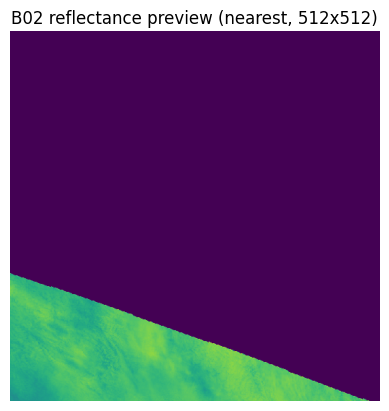

In [27]:
# Quick preview: show a heavily downsampled view for speed
with rasterio.open(jp2_path) as src:
    preview = src.read(1, out_shape=(512,512), resampling=Resampling.nearest).astype(np.float32) / QUANTIFICATION_VALUE

plt.figure()
plt.title(f"{BAND_FOR_DEBUG} reflectance preview (nearest, 512x512)")
plt.imshow(np.clip(preview, 0, 1))
plt.axis("off")
plt.show()


## 5) Masked-mean downscaling internals
We plot each intermediate: `valid`, `num`, `den`, `dst_den`, and final reflectance.

In [28]:
def masked_mean_downscale_debug(
    jp2_path: str,
    out_dim: int,
    quantification_value: float,
    *,
    band_index: int = 1,
    coverage_threshold: float = 0.0,
    resampling: Resampling = Resampling.average,
):
    with rasterio.open(jp2_path) as src:
        crs = src.crs
        src_transform = src.transform
        scale_x = src.width / out_dim
        scale_y = src.height / out_dim
        dst_transform = src_transform * Affine.scale(scale_x, scale_y)

        data = src.read(band_index).astype(np.float32)
        valid = (src.read_masks(band_index) > 0).astype(np.float32)  # 0/1
        num = data * valid
        den = valid

        dst_num = np.zeros((out_dim, out_dim), dtype=np.float32)
        dst_den = np.zeros((out_dim, out_dim), dtype=np.float32)

        reproject(
            source=num,
            destination=dst_num,
            src_transform=src_transform,
            src_crs=crs,
            dst_transform=dst_transform,
            dst_crs=crs,
            resampling=resampling,
        )
        reproject(
            source=den,
            destination=dst_den,
            src_transform=src_transform,
            src_crs=crs,
            dst_transform=dst_transform,
            dst_crs=crs,
            resampling=resampling,
        )

    with np.errstate(divide="ignore", invalid="ignore"):
        out_dn = dst_num / dst_den

    out_ref = out_dn / float(quantification_value)
    out_ref[dst_den <= max(coverage_threshold, 1e-12)] = np.nan

    return {
        "data_dn": data,
        "valid_01": valid,
        "num_dn": num,
        "den": den,
        "dst_num": dst_num,
        "dst_den": dst_den,
        "out_dn": out_dn,
        "out_ref": out_ref,
        "crs": crs,
        "dst_transform": dst_transform,
    }

dbg = masked_mean_downscale_debug(
    jp2_path,
    OUT_DIM,
    QUANTIFICATION_VALUE,
    coverage_threshold=COVERAGE_THRESHOLD,
    resampling=Resampling.average,
)

print("dst_den stats:", "min", float(np.nanmin(dbg["dst_den"])), "max", float(np.nanmax(dbg["dst_den"])))
print("out_ref stats:", "min", float(np.nanmin(dbg["out_ref"])), "max", float(np.nanmax(dbg["out_ref"])))
print("out_ref zero_frac:", float((np.nan_to_num(dbg["out_ref"])==0).mean()))


dst_den stats: min 1.0 max 1.0
out_ref stats: min 0.0 max 0.8186749815940857
out_ref zero_frac: 0.82391357421875


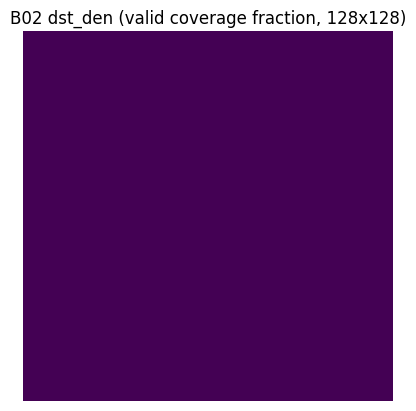

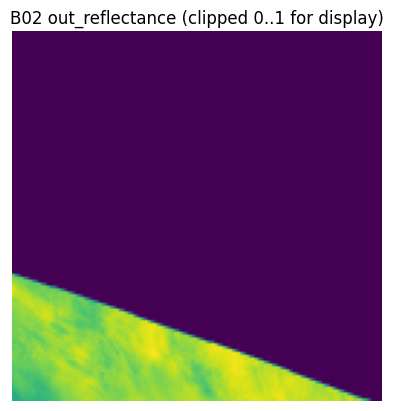

In [29]:
# Plot dst_den (coverage) and output reflectance
plt.figure()
plt.title(f"{BAND_FOR_DEBUG} dst_den (valid coverage fraction, {OUT_DIM}x{OUT_DIM})")
plt.imshow(dbg["dst_den"])
plt.axis("off")
plt.show()

plt.figure()
plt.title(f"{BAND_FOR_DEBUG} out_reflectance (clipped 0..1 for display)")
plt.imshow(np.clip(dbg["out_ref"], 0, 1))
plt.axis("off")
plt.show()


## 6) Build RGB quicklook from the cube (B04/B03/B02)
This reproduces your `write_quicklook_b432_rgba` logic, but displays inline.

[[[0.         0.         0.        ]
  [0.         0.         0.        ]
  [0.         0.         0.        ]
  ...
  [0.         0.         0.        ]
  [0.         0.         0.        ]
  [0.         0.         0.        ]]

 [[0.         0.         0.        ]
  [0.         0.         0.        ]
  [0.         0.         0.        ]
  ...
  [0.         0.         0.        ]
  [0.         0.         0.        ]
  [0.         0.         0.        ]]

 [[0.         0.         0.        ]
  [0.         0.         0.        ]
  [0.         0.         0.        ]
  ...
  [0.         0.         0.        ]
  [0.         0.         0.        ]
  [0.         0.         0.        ]]

 ...

 [[0.48255596 0.4665759  0.51021504]
  [0.5025589  0.48581102 0.53004473]
  [0.5243283  0.50457346 0.54979515]
  ...
  [0.         0.         0.        ]
  [0.         0.         0.        ]
  [0.         0.         0.        ]]

 [[0.48864815 0.47176576 0.51417094]
  [0.4721295  0.4567995  0.50005937]


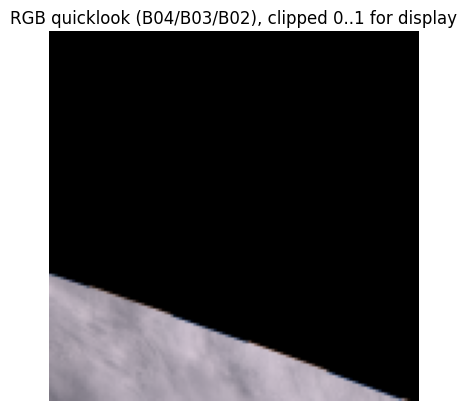

Footprint fraction (any band > 0): 0.17645263671875


In [30]:
def read_band_out_reflectance(jp2_path: str) -> np.ndarray:
    if USE_DEBUG_DOWNSCALE:
        dbg = masked_mean_downscale_debug(
            jp2_path, OUT_DIM, QUANTIFICATION_VALUE,
            coverage_threshold=COVERAGE_THRESHOLD, resampling=Resampling.average
        )
        return dbg["out_ref"]

    # FAST PATH (no change to reflectance definition; just avoids full reprojection)
    with rasterio.open(jp2_path) as src:
        dn_ds = src.read(
            1,
            out_shape=(OUT_DIM, OUT_DIM),
            resampling=Resampling.average
        ).astype(np.float32)

    out_ref = dn_ds / float(QUANTIFICATION_VALUE)
    return out_ref


r = read_band_out_reflectance(band_local_paths["B04"])
g = read_band_out_reflectance(band_local_paths["B03"])
b = read_band_out_reflectance(band_local_paths["B02"])

rgb = np.stack([r,g,b], axis=-1)
valid = np.isfinite(rgb).all(axis=-1)

rgb_plot = np.clip(rgb, 0.0, 1.0)
print(rgb_plot)
plt.figure()
plt.title("RGB quicklook (B04/B03/B02), clipped 0..1 for display")
plt.imshow(rgb_plot)
plt.axis("off")
plt.show()

print("Footprint fraction (any band > 0):", float(((rgb>0) & np.isfinite(rgb)).any(axis=2).mean()))


Build the cube

In [31]:
def build_cube_local(bands: List[str], band_local_paths: Dict[str, str]) -> np.ndarray:
    arrays = []
    for band in bands:
        arr = read_band_out_reflectance(band_local_paths[band])
        arrays.append(arr)
    return np.stack(arrays, axis=-1)  # (y, x, band)

Parallelise the workers

In [32]:
from rasterio.session import AWSSession

def process_one_safe(safe_pfx: str, use_debug_downscale: bool) -> tuple[str, np.datetime64, np.ndarray]:
    pid = safe_prefix_to_product_id(safe_pfx)
    t = sensing_time_from_product_id(pid)
    sensing_date = sensing_date_from_product_id(pid)

    # Hard-coded region
    REGION = "eu-central-1"

    # Proper boto3 session with explicit region
    boto_sess = boto3.Session(
        profile_name="source-keys",
        region_name=REGION
    )

    s3_local = boto_sess.client("s3", config=S3_CONFIG)

    tiles_prefix = tile_to_tiles_prefix(get_mgrs_tile_from_product_id(pid), sensing_date)
    all_keys = list_s3_objects_requester_pays(s3_local, IN_BUCKET, tiles_prefix)
    band_to_key = find_jp2_band_keys(all_keys, BANDS)

    # if pid.endswith("20161207T231127") or "20161207" in pid:
    #     print("DEBUG pid:", pid)
    #     for b in ["B01", "B02", "B03"]:
    #         print(" ", b, "->", band_to_key[b])
    cube_data = []

    aws_rio_sess = AWSSession(boto_sess)

    with rasterio.Env(
        aws_rio_sess,
        AWS_REGION=REGION,
        AWS_REQUEST_PAYER="requester",
        GDAL_DISABLE_READDIR_ON_OPEN="EMPTY_DIR",
        GDAL_HTTP_MERGE_CONSECUTIVE_RANGES="YES",
        GDAL_HTTP_MULTIPLEX="YES",
        GDAL_HTTP_VERSION="2",
        VSI_CACHE="TRUE",
        VSI_CACHE_SIZE="50000000",
    ):
        for band in BANDS:
            key = band_to_key[band]
            s3_path = f"s3://{IN_BUCKET}/{key}"

            with rasterio.open(s3_path) as src:
                dn_ds = src.read(
                    1,
                    out_shape=(OUT_DIM, OUT_DIM),
                    resampling=Resampling.average
                ).astype(np.float32)

            cube_data.append(dn_ds / float(QUANTIFICATION_VALUE))

    cube_i = np.stack(cube_data, axis=0).transpose(1, 2, 0).astype(np.float32)
    return pid, t, cube_i

Zarr stacking helper methods

In [33]:
def write_debug_single_time_zarr(
    band_names, band_local_paths, product_id, safe_prefix, tile,
    out_dim, quant_val, cov_thresh, in_bucket, tmp_dir
):
    cube = build_cube_local(band_names, band_local_paths)
    t0 = sensing_time_from_product_id(product_id)
    debug_pid = safe_prefix_to_product_id(safe_prefix)

    ds = xr.Dataset(
        data_vars={"reflectance": (["time", "y", "x", "band"], cube[None, ...])},
        coords={
            "time": ("time", np.array([t0])),
            "y": np.arange(cube.shape[0]),
            "x": np.arange(cube.shape[1]),
            "band": np.arange(cube.shape[2]),
            "band_name": ("band", band_names),
            "system_index": ("time", np.array([debug_pid], dtype=f"U{len(debug_pid)}")),
        },
        attrs={
            "mgrs_tile": tile,
            "processing": "Masked-mean downscaling: average(DN*valid)/average(valid) using read_masks; DN scaled to reflectance",
            "quantification_value_divisor": float(quant_val),
            "coverage_threshold": float(cov_thresh),
            "out_dim": int(out_dim),
            "source_bucket": in_bucket,
            "note": "This dataset is the DEBUG product only (time dimension length=1).",
        },
    )

    out_path = os.path.join(tmp_dir, "debug_out_single_time.zarr")
    ds = ds.chunk({"time": 1, "y": out_dim, "x": out_dim, "band": len(band_names)})
    ds.to_zarr(out_path, mode="w", consolidated=True)
    return out_path


def load_existing_store_state(local_zarr):
    """Return (wrote, existing_set, pid_dtype_len_from_store_or_None, time_chunk_or_None, ds_existing_or_None)."""
    if not os.path.exists(local_zarr):
        return False, set(), None, None, None

    try:
        ds_existing = xr.open_zarr(local_zarr, consolidated=False)
        store_u = ds_existing["system_index"].dtype.itemsize // 4  # U len
        existing = set(map(str, ds_existing["system_index"].values.tolist()))
        time_chunk = int(ds_existing["reflectance"].chunks[0][0])
        return True, existing, store_u, time_chunk, ds_existing
    except Exception as e:
        print(f"[WARN] Could not open existing Zarr for resume: {e!r}")
        return False, set(), None, None, None


def dedup_safe_prefixes(safe_prefixes):
    seen = set()
    unique = []
    for pfx in safe_prefixes:
        pid = safe_prefix_to_product_id(pfx)
        if pid not in seen:
            seen.add(pid)
            unique.append(pfx)
    return unique


def compute_georef_once(
    s3, in_bucket, tile, out_dim,
    safe_prefixes, existing,
):
    """Compute x/y/crs/transform from first new timestep (B02) to set common coords."""
    pid0 = None
    safe0 = None
    for safe_pfx0 in safe_prefixes:
        p0 = safe_prefix_to_product_id(safe_pfx0)
        if p0 not in existing:
            pid0, safe0 = p0, safe_pfx0
            break

    if pid0 is None:
        return None, None, None, None  # nothing new

    sensing_date0 = sensing_date_from_product_id(pid0)
    tiles_prefix0 = tile_to_tiles_prefix(get_mgrs_tile_from_product_id(pid0), sensing_date0)
    all_keys0 = list_s3_objects_requester_pays(s3, in_bucket, tiles_prefix0)
    b02_key0 = find_jp2_band_keys(all_keys0, ["B02"])["B02"]

    tmp0 = tempfile.mkdtemp(prefix="ai4qc2_georef_", dir=TMP_ROOT)
    try:
        b02_path0 = os.path.join(tmp0, "B02.jp2")
        download_s3_object_requester_pays(s3, in_bucket, b02_key0, b02_path0)
        with rasterio.open(b02_path0) as src:
            crs_wkt = src.crs.to_wkt()
            transform = src.transform
            dst_transform = transform * Affine.scale(src.width / out_dim, src.height / out_dim)

        cols = np.arange(out_dim)
        rows = np.arange(out_dim)
        x_easting, _ = dst_transform * (cols + 0.5, np.zeros_like(cols) + 0.5)
        _, y_northing = dst_transform * (np.zeros_like(rows) + 0.5, rows + 0.5)

        return np.asarray(x_easting, dtype=np.float64), np.asarray(y_northing, dtype=np.float64), crs_wkt, dst_transform
    finally:
        shutil.rmtree(tmp0, ignore_errors=True)


def make_ds_block(pids, times, cubes, band_names, out_dim, pid_dtype_len, x_easting, y_northing, time_chunk):
    block = np.stack(cubes, axis=0)  # (time, y, x, band)
    pid_u = np.array(pids, dtype=f"U{pid_dtype_len}")
    t_ns = np.array(times, dtype="datetime64[ns]")

    ds = xr.Dataset(
        data_vars={"reflectance": (["time", "y", "x", "band"], block)},
        coords={
            "time": ("time", t_ns),
            "y": ("y", y_northing),
            "x": ("x", x_easting),
            "band": np.arange(len(band_names)),
            "band_name": ("band", band_names),
            "system_index": ("time", pid_u),
        },
    )

    ds = ds.chunk({"time": min(time_chunk, block.shape[0]), "y": out_dim, "x": out_dim, "band": len(band_names)})

    ds["x"].attrs.update({"standard_name": "projection_x_coordinate", "units": "m"})
    ds["y"].attrs.update({"standard_name": "projection_y_coordinate", "units": "m"})
    ds["time"].encoding = {
        "units": "nanoseconds since 1970-01-01 00:00:00",
        "calendar": "proleptic_gregorian",
        "dtype": "int64",
    }
    return ds


def finalize_store_attrs(local_zarr, crs_wkt=None, dst_transform=None):
    ds_final = xr.open_zarr(local_zarr, consolidated=False, decode_times=False)
    tvals = ds_final["time"].values.astype("int64")

    attrs = dict(ds_final.attrs)
    if tvals.size:
        attrs.update({"time_start_ns": int(tvals.min()), "time_end_ns": int(tvals.max()), "num_timesteps": int(tvals.size)})
    else:
        attrs.update({"num_timesteps": 0})

    if (crs_wkt is not None) and (dst_transform is not None):
        attrs.update({
            "crs_wkt": crs_wkt,
            "dst_transform_gdal": tuple(dst_transform.to_gdal()),
            "dst_transform_affine": [dst_transform.a, dst_transform.b, dst_transform.c,
                                     dst_transform.d, dst_transform.e, dst_transform.f],
        })

    ds_final.assign_attrs(attrs).to_zarr(local_zarr, mode="a", consolidated=True)

## 7) Optional: write Zarr locally (no upload)
This writes the same dataset structure your script writes, but to a local folder so you can open and inspect quickly.

In [ ]:
# (A) DEBUG single-time Zarr
local_debug_zarr = write_debug_single_time_zarr(
    BANDS, band_local_paths, product_id, SAFE_PREFIX, tile,
    OUT_DIM, QUANTIFICATION_VALUE, COVERAGE_THRESHOLD, IN_BUCKET, ZARR_DIR
)
local_debug_zarr

import time
t_start = time.time()
n_done = 0

# (B) FULL time-stacked cube
BUILD_TIME_STACK = True
if not BUILD_TIME_STACK:
    raise SystemExit("Time stack build disabled.")

local_time_zarr = os.path.join(ZARR_DIR, ZARR_NAME)

wrote, existing, store_u, time_chunk_existing, _ = load_existing_store_state(local_time_zarr)
pid_dtype_len = store_u if store_u is not None else PID_DTYPE_LEN

TIME_CHUNK = time_chunk_existing if (time_chunk_existing is not None) else (BATCH_SIZE if USE_BATCH_WRITES else 1)
print("Resume:", wrote, "| existing:", len(existing), "| pid dtype:", pid_dtype_len, "| time_chunk:", TIME_CHUNK)

safe_prefixes = dedup_safe_prefixes(safe_prefixes)
print("SAFE prefixes after dedup:", len(safe_prefixes))

x_easting, y_northing, crs_wkt, dst_transform = compute_georef_once(s3, IN_BUCKET, TILE, OUT_DIM, safe_prefixes, existing)
if x_easting is None:
    print("Nothing new to process (all in existing).")
    local_time_zarr

base_attrs = {
    "mgrs_tile": TILE,
    "processing": "...",
    "quantification_value_divisor": float(QUANTIFICATION_VALUE),
    "coverage_threshold": float(COVERAGE_THRESHOLD),
    "out_dim": int(OUT_DIM),
    "source_bucket": IN_BUCKET,
}
if (crs_wkt is not None) and (dst_transform is not None):
    base_attrs.update({"crs_wkt": crs_wkt, "dst_transform_gdal": tuple(dst_transform.to_gdal())})

to_submit = sorted(
    [pfx for pfx in safe_prefixes if safe_prefix_to_product_id(pfx) not in existing],
    key=lambda pfx: extract_datetime_token(safe_prefix_to_product_id(pfx))
)
print(f"Submitting {len(to_submit)} timesteps to {MAX_WORKERS} workers...")

failure_log = os.path.join(LOG_DIR, "failures.jsonl")
batch_pids, batch_times, batch_cubes = [], [], []

# with ProcessPoolExecutor(max_workers=MAX_WORKERS) as ex:
#     for j, (pid, t, cube_i) in enumerate(ex.map(process_one_safe, to_submit, repeat(False)), start=1):
#         try:
#             if pid in existing or pid in batch_pids:
#                 continue
#             if len(pid) > pid_dtype_len:
#                 raise ValueError(f"pid too long for store dtype U{pid_dtype_len}: {pid} (len={len(pid)})")

#             batch_pids.append(pid); batch_times.append(t); batch_cubes.append(cube_i)

#             should_flush = (not USE_BATCH_WRITES) or (len(batch_pids) >= BATCH_SIZE)
#             if should_flush:
#                 ds_block = make_ds_block(batch_pids, batch_times, batch_cubes, BANDS, OUT_DIM, pid_dtype_len, x_easting, y_northing, TIME_CHUNK)

#                 if not wrote:
#                     ds_block.assign_attrs(base_attrs).to_zarr(local_time_zarr, mode="w", consolidated=True)
#                     wrote = True
#                 else:
#                     ds_block.to_zarr(local_time_zarr, mode="a", append_dim="time", consolidated=False)

#                 flushed = len(batch_pids)          # count before resetting
# 1. Use ThreadPoolExecutor for I/O bound Rasterio reads
from concurrent.futures import as_completed
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
    future_to_pfx = {ex.submit(process_one_safe, pfx, False): pfx for pfx in to_submit}
    
    for future in as_completed(future_to_pfx):
        try:
            pid, t, cube_i = future.result()
            
            if pid in existing or pid in batch_pids:
                continue
            batch_pids.append(pid)
            batch_times.append(t)
            batch_cubes.append(cube_i)

            # 3. Check if we have enough for a batch write
            should_flush = (not USE_BATCH_WRITES) or (len(batch_pids) >= BATCH_SIZE)
            if len(batch_pids) >= BATCH_SIZE:
                ds_block = make_ds_block(
                    batch_pids, batch_times, batch_cubes, 
                    BANDS, OUT_DIM, pid_dtype_len, 
                    x_easting, y_northing, TIME_CHUNK
                )

                if not wrote:
                    ds_block.assign_attrs(base_attrs).to_zarr(local_time_zarr, mode="w", consolidated=True)
                    wrote = True
                else:
                    Consolidated=False 
                    ds_block.to_zarr(local_time_zarr, mode="a", append_dim="time", consolidated=False)

                flushed = len(batch_pids)
                n_done += len(batch_pids)
                existing.update(batch_pids)
                
                # Report Progress
                elapsed = time.time() - t_start
                print(f"Wrote {n_done} timesteps. Rate: {n_done/(elapsed/60):.2f} ts/min")
            
                # Clear Batch
                batch_pids, batch_times, batch_cubes = [], [], []


            # existing.update(batch_pids)
            # batch_pids, batch_times, batch_cubes = [], [], []

            # n_done += flushed
            # elapsed = time.time() - t_start
            # rate = n_done / (elapsed / 60.0)
            # print(f"Wrote {n_done} timesteps in {elapsed/60:.1f} min => {rate:.2f} timesteps/min")

            # if j % 25 == 0:
            #     print(f"Processed {j}/{len(to_submit)} timesteps")

        # except Exception as e:
        #     log_failure(failure_log, pid if "pid" in locals() else "UNKNOWN", stage="parallel_bulk", err=e)
        #     print(f"[WARN] parallel timestep failed: {e!r}")
        except Exception as e:
            pfx = future_to_pfx[future]
            print(f"[ERROR] Step {pfx} failed: {e}")
if batch_pids:
    ds_block = make_ds_block(batch_pids, batch_times, batch_cubes, BANDS, OUT_DIM, pid_dtype_len, x_easting, y_northing, TIME_CHUNK)
    if not wrote:
        ds_block.assign_attrs(base_attrs).to_zarr(local_time_zarr, mode="w", consolidated=True)
        wrote = True
    else:
        ds_block.to_zarr(local_time_zarr, mode="a", append_dim="time", consolidated=False)
    existing.update(batch_pids)

if wrote:
    finalize_store_attrs(local_time_zarr, crs_wkt=crs_wkt, dst_transform=dst_transform)

local_time_zarr

/home/ubuntu/AI4QC2_HIGH/.venv/lib/python3.12/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=60, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)
/home/ubuntu/AI4QC2_HIGH/.venv/lib/python3.12/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=3, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr P

Resume: True | existing: 256 | pid dtype: 128 | time_chunk: 128
SAFE prefixes after dedup: 805
Submitting 549 timesteps to 10 workers...


ERROR 1: URL rejected: Malformed input to a URL function
ERROR 1: URL rejected: Malformed input to a URL function
ERROR 1: URL rejected: Malformed input to a URL function
ERROR 1: URL rejected: Malformed input to a URL function
ERROR 1: URL rejected: Malformed input to a URL function
ERROR 1: URL rejected: Malformed input to a URL function
ERROR 1: URL rejected: Malformed input to a URL function
ERROR 1: URL rejected: Malformed input to a URL function
ERROR 1: URL rejected: Malformed input to a URL function
ERROR 1: URL rejected: Malformed input to a URL function
ERROR 1: URL rejected: Malformed input to a URL function
ERROR 1: URL rejected: Malformed input to a URL function
ERROR 1: URL rejected: Malformed input to a URL function
ERROR 1: URL rejected: Malformed input to a URL function
ERROR 1: URL rejected: Malformed input to a URL function
ERROR 1: URL rejected: Malformed input to a URL function
ERROR 1: URL rejected: Malformed input to a URL function
ERROR 1: URL rejected: Malforme

## 8) Cleanup
Delete the temporary download folder when you're done.

Quick structural sanity checks

In [ ]:
import xarray as xr
import numpy as np

z = os.path.join(tmp, f"s2_l1c_tile_{TILE}_{START_DATE}_to_{END_DATE}.zarr")
ds = xr.open_zarr(local_time_zarr, consolidated=False)

print(ds)
print("dims:", ds.dims)
print("reflectance dtype:", ds["reflectance"].dtype)
print("reflectance shape:", ds["reflectance"].shape)
print("band_name:", ds["band_name"].values.tolist())
print("time count:", ds.dims["time"])
print("time min/max:", ds["time"].values.min(), ds["time"].values.max())
print("unique system_index count:", len(np.unique(ds["system_index"].values)))


In [ ]:
import matplotlib.pyplot as plt

tidx = 0
B04 = int(np.where(ds["band_name"].values == "B04")[0][0])
B03 = int(np.where(ds["band_name"].values == "B03")[0][0])
B02 = int(np.where(ds["band_name"].values == "B02")[0][0])

rgb = np.stack([
    ds["reflectance"].isel(time=tidx, band=B04).values,
    ds["reflectance"].isel(time=tidx, band=B03).values,
    ds["reflectance"].isel(time=tidx, band=B02).values,
], axis=-1)

plt.figure()
plt.title(f"RGB quicklook time idx {tidx} {ds['time'].values[tidx]}")
plt.imshow(np.clip(rgb, 0, 1))
plt.axis("off")
plt.show()
